# Graph LP Solver

Define L(C, G, T) edges as a graph. Nodes are monodromy invariants — some fixed (known gates/targets), some free (LP variables). Edges are QLR constraints. The LP finds feasible values for the free nodes.

In [118]:
import numpy as np
from docplex.mp.model import Model
from docplex.mp.dvar import Var

from gulps.core.invariants import GateInvariants
from gulps.linear_program.qlr import len_qlr, qlr_inequalities
from gulps.viz.invariant_viz import _render_path

In [ ]:
import numpy as np
from docplex.mp.model import Model
from docplex.mp.dvar import Var

from gulps.core.invariants import GateInvariants
from gulps.linear_program.qlr import len_qlr, qlr_inequalities
from gulps._accelerate import canonical_matrix as _rust_can
from gulps.viz.weyl_chamber import WeylChamber

_ci_block, _gi_block, _ciplus1_block, _bi = qlr_inequalities


def W(c1, c2, c3):
    """Create GateInvariants from Weyl coordinates."""
    return GateInvariants.from_unitary(np.array(_rust_can(c1, c2, c3)))


def plot_path(invariants, labels=None, ax=None):
    """Plot a path through the Weyl chamber."""
    import matplotlib.pyplot as plt

    if ax is None:
        fig = plt.figure(figsize=(6, 5))
        ax = fig.add_subplot(111, projection="3d")
    wc = WeylChamber()
    wc.labels = {}
    wc.render(ax)
    pts = np.array([inv.weyl for inv in invariants])
    ax.plot(
        pts[:, 0], pts[:, 1], pts[:, 2], "o-", color="steelblue", ms=8, lw=2, zorder=5
    )
    if labels:
        for pt, lbl in zip(pts, labels):
            ax.text(pt[0], pt[1], pt[2], f"  {lbl}", fontsize=9, zorder=6)
    plt.tight_layout()


class GraphLP:
    """Graph-based LP solver for monodromy feasibility.

    Nodes are monodromy invariants (3-vectors). Each node is either:
      - fixed: a known GateInvariants (gate, prefix, target)
      - free: an LP variable to be determined

    Edges are L(c_prev, g, c_next) QLR constraints.
    Each edge has a FIXED gate g and connects two nodes.
    """

    def __init__(self):
        self.model = Model("GraphLP", ignore_names=True)
        self._nodes: dict[str, dict] = {}
        self._edges: list[tuple[str, str, str]] = []
        self._free_vars: list = []

    def add_fixed_node(self, name: str, invariant: GateInvariants):
        """Add a node with known, fixed monodromy coordinates."""
        self._nodes[name] = {
            "type": "fixed",
            "mono": np.asarray(invariant.monodromy, dtype=np.float64),
            "invariant": invariant,
        }

    def add_free_node(self, name: str):
        """Add a node whose monodromy coordinates are LP variables."""
        vars_ = self.model.continuous_var_list(3, lb=-1.0, ub=1.0, name=name)
        self._nodes[name] = {"type": "free", "vars": vars_}
        self._free_vars.extend(vars_)

    def add_edge(self, src: str, gate: GateInvariants, dst: str, label: str = ""):
        """Add QLR constraint: L(src, gate, dst) <= b."""
        assert src in self._nodes, f"Unknown node: {src}"
        assert dst in self._nodes, f"Unknown node: {dst}"

        g_mono = np.asarray(gate.monodromy, dtype=np.float64)
        c_prev = self._get_node_expr(src)
        c_next = self._get_node_expr(dst)

        for r in range(len_qlr):
            lhs = 0.0
            for x, coeff in [
                (c_prev, _ci_block[r]),
                (g_mono, _gi_block[r]),
                (c_next, _ciplus1_block[r]),
            ]:
                if isinstance(x, np.ndarray):
                    lhs += float(np.dot(x, coeff))
                else:
                    lhs += self.model.scal_prod(x, coeff)

            if isinstance(lhs, (int, float)):
                if lhs > float(_bi[r]) + 1e-10:
                    raise ValueError(
                        f"Edge {src}→{dst} (fixed-fixed): infeasible at row {r}"
                    )
            else:
                self.model.add_constraint(lhs <= float(_bi[r]))

        self._edges.append((src, label or gate.name or "G", dst))

    def solve(self, log_output: bool = False) -> dict[str, GateInvariants] | None:
        """Solve the LP. Returns dict of node name → GateInvariants, or None."""
        if self._free_vars:
            self.model.maximize(self.model.sum(self._free_vars))
        sol = self.model.solve(log_output=log_output)
        if sol is None:
            return None
        result = {}
        for name, node in self._nodes.items():
            if node["type"] == "free":
                vals = tuple(sol.get_value(v) for v in node["vars"])
                result[name] = GateInvariants(vals)
            else:
                result[name] = node["invariant"]
        return result

    def _get_node_expr(self, name: str):
        node = self._nodes[name]
        return node["mono"] if node["type"] == "fixed" else node["vars"]

    def summary(self):
        fixed = [(n, d) for n, d in self._nodes.items() if d["type"] == "fixed"]
        free = [(n, d) for n, d in self._nodes.items() if d["type"] == "free"]
        print(f"Nodes: {len(fixed)} fixed, {len(free)} free")
        for name, node in fixed:
            w = node["invariant"].weyl
            print(f"  {name:>10s} [fixed]  weyl=({w[0]:.4f}, {w[1]:.4f}, {w[2]:.4f})")
        for name, _ in free:
            print(f"  {name:>10s} [free]")
        print(f"Edges: {len(self._edges)}")
        for src, label, dst in self._edges:
            print(f"  {src} --[{label}]--> {dst}")

    def print_result(self, result: dict):
        for name, inv in result.items():
            if self._nodes[name]["type"] == "free":
                w = inv.weyl
                gap = min(abs(w[0] - w[1]), abs(w[1] - w[2]))
                degen = " *** DEGEN" if gap < 0.02 else ""
                print(
                    f"  {name:>10s}: weyl=({w[0]:.4f}, {w[1]:.4f}, {w[2]:.4f})  gap={gap:.4f}{degen}"
                )

## Example 1: Standard chain L(C, G, T)

A single segment: fixed C and T, one gate G, no free nodes (pure feasibility check).

In [ ]:
# --- Common gates ---
iswap = W(0.5, 0.5, 0.0)
xx05 = W(0.5, 0.0, 0.0)  # CX
yy05 = W(0.0, 0.5, 0.0)

C = W(0.3, 0.2, 0.1)
T = W(0.3, 0.3, 0.0)  # degenerate (c1=c2)

# Standard: C --[iSWAP]--> T
g = GraphLP()
g.add_fixed_node("C", C)
g.add_fixed_node("T", T)
g.add_edge("C", iswap, "T", label="iSWAP")
g.summary()
print(f"\nFeasible: {g.solve() is not None}")

Nodes: 2 fixed, 0 free
           C [fixed]  weyl=(0.3000, 0.2000, 0.1000)
           T [fixed]  weyl=(0.3000, 0.3000, 0.0000)
Edges: 1
  C --[iSWAP]--> T

Feasible: True


## Example 2: Sub-gate chain with free intermediate

Split iSWAP = XX · YY. Introduce free node M between them.

```
C --[XX]--> M --[YY]--> T
```

Nodes: 2 fixed, 1 free
           C [fixed]  weyl=(0.3000, 0.2000, 0.1000)
           T [fixed]  weyl=(0.3000, 0.3000, 0.0000)
           M [free]
Edges: 2
  C --[XX]--> M
  M --[YY]--> T
           M: weyl=(0.6000, 0.3000, 0.2000)  gap=0.1000


/tmp/ipykernel_3619681/3693384404.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


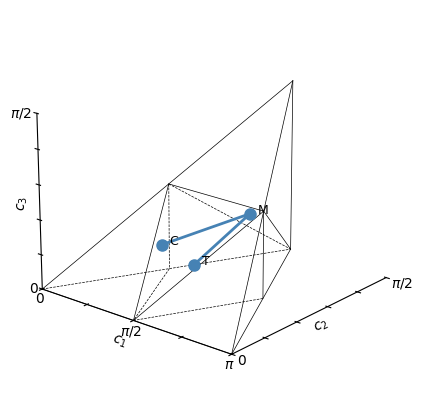

In [121]:
# Sub-gate: C --[XX]--> M --[YY]--> T
g = GraphLP()
g.add_fixed_node("C", C)
g.add_free_node("M")
g.add_fixed_node("T", T)

g.add_edge("C", xx05, "M", label="XX")
g.add_edge("M", yy05, "T", label="YY")
g.summary()

result = g.solve()
if result:
    g.print_result(result)
    plot_path([C, result["M"], T], labels=["C", "M", "T"])
else:
    print("\nInfeasible")

## Example 3: Sub-gate + regrouping edge

Same as above, but add the regrouping constraint as an extra edge:
the original L(C, iSWAP, T) must also be feasible.

```
C --[XX]--> M --[YY]--> T
C --[iSWAP]-----------> T   (regrouping)
```

Nodes: 2 fixed, 1 free
           C [fixed]  weyl=(0.3000, 0.2000, 0.1000)
           T [fixed]  weyl=(0.3000, 0.3000, 0.0000)
           M [free]
Edges: 3
  C --[XX]--> M
  M --[YY]--> T
  C --[iSWAP (regroup)]--> T
           M: weyl=(0.6000, 0.3000, 0.2000)  gap=0.1000


/tmp/ipykernel_3619681/3693384404.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


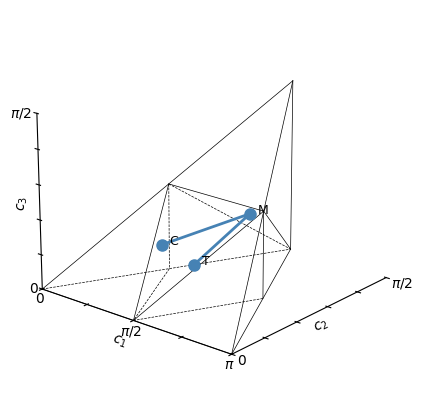

In [122]:
# Sub-gate + regrouping
g = GraphLP()
g.add_fixed_node("C", C)
g.add_free_node("M")
g.add_fixed_node("T", T)

g.add_edge("C", xx05, "M", label="XX")
g.add_edge("M", yy05, "T", label="YY")
g.add_edge("C", iswap, "T", label="iSWAP (regroup)")
g.summary()

result = g.solve()
if result:
    g.print_result(result)
    plot_path([C, result["M"], T], labels=["C", "M", "T"])
else:
    print("\nInfeasible")

## Example 4: Multi-segment with sub-gate expansion

A 2-iSWAP decomposition: C → M₁ → T via two iSWAP gates.
Expand each iSWAP into XX+YY sub-gates with free intermediates.

```
C --[XX]--> A --[YY]--> M₁ --[XX]--> B --[YY]--> T
C --[iSWAP]-----------> M₁ --[iSWAP]-----------> T   (regrouping)
```

Nodes: 2 fixed, 3 free
           C [fixed]  weyl=(0.3000, 0.2000, 0.1000)
           T [fixed]  weyl=(0.5000, 0.5000, 0.2500)
           A [free]
          M1 [free]
           B [free]
Edges: 6
  C --[XX₁]--> A
  A --[YY₁]--> M1
  M1 --[XX₂]--> B
  B --[YY₂]--> T
  C --[iSWAP₁]--> M1
  M1 --[iSWAP₂]--> T
           A: weyl=(0.6000, 0.3000, 0.2000)  gap=0.1000
          M1: weyl=(0.5000, 0.2500, 0.0000)  gap=0.2500
           B: weyl=(0.5000, 0.5000, 0.2500)  gap=0.0000 *** DEGEN


/tmp/ipykernel_3619681/3693384404.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


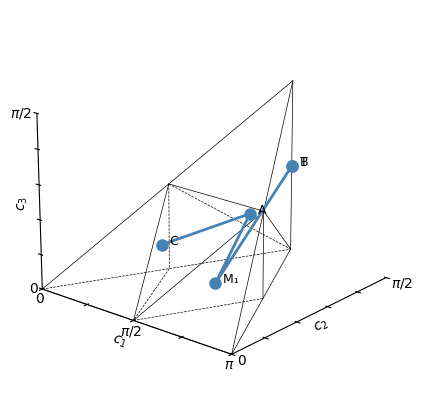

In [ ]:
# 2-iSWAP with sub-gate expansion
T2 = W(0.5, 0.5, 0.25)  # needs 2 iSWAPs

g = GraphLP()
g.add_fixed_node("C", C)
g.add_free_node("A")
g.add_free_node("M1")
g.add_free_node("B")
g.add_fixed_node("T", T2)

# Sub-gate edges
g.add_edge("C", xx05, "A", label="XX₁")
g.add_edge("A", yy05, "M1", label="YY₁")
g.add_edge("M1", xx05, "B", label="XX₂")
g.add_edge("B", yy05, "T", label="YY₂")

# Regrouping
g.add_edge("C", iswap, "M1", label="iSWAP₁")
g.add_edge("M1", iswap, "T", label="iSWAP₂")

g.summary()

result = g.solve()
if result:
    g.print_result(result)
    plot_path(
        [C, result["A"], result["M1"], result["B"], T2],
        labels=["C", "A", "M₁", "B", "T"],
    )
else:
    print("Infeasible")

## Sub-gate decomposition with partial regrouping

Given G = XX(a)·YY(b)·ZZ(c), six coupled QLR constraints on (M1, M2):

```
L(C,  G,     T)      regrouping (full)
L(C,  XX,    M1)     sub-gate 1
L(M1, YY,    M2)     sub-gate 2
L(M2, ZZ,    T)      sub-gate 3
L(C,  XXYY,  M2)     partial regroup (skip M1: XX·YY combined)
L(M1, YYZZ,  T)      partial regroup (skip M2: YY·ZZ combined)
```

Nodes: 2 fixed, 2 free
           C [fixed]  weyl=(0.3000, 0.2000, 0.1000)
           T [fixed]  weyl=(0.3000, 0.3000, 0.0000)
          M1 [free]
          M2 [free]
Edges: 6
  C --[G (regroup)]--> T
  C --[XX]--> M1
  M1 --[YY]--> M2
  M2 --[ZZ]--> T
  C --[XX·YY (skip M1)]--> M2
  M1 --[YY·ZZ (skip M2)]--> T
          M1: weyl=(0.6000, 0.3000, 0.2000)  gap=0.1000
          M2: weyl=(0.3000, 0.3000, 0.0000)  gap=0.0000 *** DEGEN


/tmp/ipykernel_3619681/3693384404.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


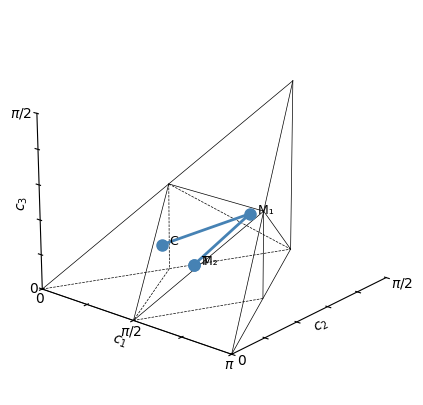

In [ ]:
# --- Parameters ---
a, b, c = 0.5, 0.5, 0.0  # iSWAP

G = W(a, b, c)
XX = W(a, 0, 0)
YY = W(0, b, 0)
ZZ_g = W(0, 0, c) if c > 1e-10 else W(0, 0, 0)
XXYY = W(a, b, 0)
YYZZ = W(0, b, c)

C = W(0.3, 0.2, 0.1)
T = W(0.3, 0.3, 0.0)  # degenerate

g = GraphLP()
g.add_fixed_node("C", C)
g.add_free_node("M1")
g.add_free_node("M2")
g.add_fixed_node("T", T)

# 6 edges
g.add_edge("C", G, "T", label="G (regroup)")
g.add_edge("C", XX, "M1", label="XX")
g.add_edge("M1", YY, "M2", label="YY")
g.add_edge("M2", ZZ_g, "T", label="ZZ")
g.add_edge("C", XXYY, "M2", label="XX·YY (skip M1)")
g.add_edge("M1", YYZZ, "T", label="YY·ZZ (skip M2)")

g.summary()
result = g.solve()
if result:
    g.print_result(result)
    plot_path([C, result["M1"], result["M2"], T], labels=["C", "M₁", "M₂", "T"])
else:
    print("Infeasible")

## Sweep: M1, M2 gap vs target degeneracy

For a range of (C, T) pairs, run the 6-constraint LP and check whether M1 is generic.

In [ ]:
from qiskit.synthesis import TwoQubitWeylDecomposition
from qiskit.quantum_info import Operator


def kak_of(gate_inv):
    """Return (K_L, weyl, K_R) of a GateInvariants."""
    U = gate_inv.matrix
    d = TwoQubitWeylDecomposition(Operator(U))
    c = np.array([d.a, d.b, d.c]) / (np.pi / 2)
    K_L = np.kron(d.K1l, d.K1r)
    K_R = np.kron(d.K2l, d.K2r)
    return K_L, c, K_R


def subgate_lp(C_inv, G_inv, T_inv):
    """Run the 6-constraint sub-gate LP for L(C, G, T).

    Splits G's canonical form into XX(a)·YY(b)·ZZ(c) and finds M1, M2.
    Returns dict with M1, M2 GateInvariants or None if infeasible.
    """
    w = G_inv.weyl
    a, b, c = float(w[0]), float(w[1]), float(w[2])

    G = G_inv
    XX = W(a, 0, 0)
    YY = W(0, b, 0)
    ZZ = W(0, 0, c) if c > 1e-10 else W(0, 0, 0)
    XXYY = W(a, b, 0)
    YYZZ = W(0, b, c)

    g = GraphLP()
    g.add_fixed_node("C", C_inv)
    g.add_free_node("M1")
    g.add_free_node("M2")
    g.add_fixed_node("T", T_inv)

    try:
        g.add_edge("C", G, "T", label="G")
    except ValueError:
        return None  # L(C, G, T) itself is infeasible
    g.add_edge("C", XX, "M1", label="XX")
    g.add_edge("M1", YY, "M2", label="YY")
    g.add_edge("M2", ZZ, "T", label="ZZ")
    try:
        g.add_edge("C", XXYY, "M2", label="XXYY")
    except ValueError:
        pass  # degenerate: XXYY edge fixed-fixed infeasible
    g.add_edge("M1", YYZZ, "T", label="YYZZ")

    return g.solve()


def weyl_gap(inv):
    w = inv.weyl
    return min(abs(w[0] - w[1]), abs(w[1] - w[2]))


# --- Sweep over degenerate targets ---
from gulps._accelerate import solve_batch
import time

G_inv = W(0.5, 0.5, 0.0)  # iSWAP
G_mat = G_inv.matrix

print("Gate: iSWAP = (0.5, 0.5, 0.0)")
print(
    f"\n{'C weyl':>24s}  {'T weyl':>24s}  T_gap  LP_ok  {'M1 weyl':>24s}  M1_gap  {'Rust(ms)':>8s}"
)
print("-" * 130)

np.random.seed(42)

test_pairs = []
c_weyl = (0.3, 0.2, 0.1)
C_inv = W(*c_weyl)
C_mat = C_inv.matrix

# Degenerate targets
for t in [
    (0.25, 0.25, 0),
    (0.3, 0.3, 0),
    (0.3, 0.3, 0.1),
    (0.35, 0.35, 0.05),
    (0.4, 0.4, 0),
    (0.4, 0.4, 0.1),
    (0.375, 0.375, 0),
    (0.375, 0.375, 0.125),
]:
    test_pairs.append((c_weyl, t))

# Random feasible targets
from gulps._accelerate import weyl_coordinates

for _ in range(10):
    q = np.random.randn(4)
    q /= np.linalg.norm(q)
    a, b, c, d = q
    u0 = np.array([[a + 1j * b, c + 1j * d], [-c + 1j * d, a - 1j * b]])
    q = np.random.randn(4)
    q /= np.linalg.norm(q)
    a, b, c, d = q
    u1 = np.array([[a + 1j * b, c + 1j * d], [-c + 1j * d, a - 1j * b]])
    prod = G_mat @ np.kron(u1, u0) @ C_mat
    tw = tuple(float(x) for x in weyl_coordinates(prod))
    test_pairs.append((c_weyl, tw))

# Different prefixes
for cw in [(0.4, 0.4, 0.1), (0.1, 0.05, 0), (0.3, 0, 0), (0.25, 0.25, 0)]:
    C_tmp = W(*cw)
    for _ in range(3):
        q = np.random.randn(4)
        q /= np.linalg.norm(q)
        a, b, c, d = q
        u0 = np.array([[a + 1j * b, c + 1j * d], [-c + 1j * d, a - 1j * b]])
        q = np.random.randn(4)
        q /= np.linalg.norm(q)
        a, b, c, d = q
        u1 = np.array([[a + 1j * b, c + 1j * d], [-c + 1j * d, a - 1j * b]])
        prod = G_mat @ np.kron(u1, u0) @ np.array(C_tmp.matrix)
        tw = tuple(float(x) for x in weyl_coordinates(prod))
        test_pairs.append((cw, tw))

n_feasible = 0
n_generic_m1 = 0
n_total = 0

for c_weyl, t_weyl in test_pairs:
    C_inv = W(*c_weyl)
    T_inv = W(*t_weyl)
    t_gap = weyl_gap(T_inv)

    result = subgate_lp(C_inv, G_inv, T_inv)

    t0 = time.perf_counter()
    res = solve_batch([C_inv.matrix], [G_inv.matrix], [T_inv.matrix], 1e-9, 1e-5)
    dt = (time.perf_counter() - t0) * 1000

    n_total += 1
    c_str = f"({c_weyl[0]:.2f},{c_weyl[1]:.2f},{c_weyl[2]:.2f})"
    t_str = f"({t_weyl[0]:.3f},{t_weyl[1]:.3f},{t_weyl[2]:.3f})"

    if result:
        n_feasible += 1
        M1 = result["M1"]
        m1_gap = weyl_gap(M1)
        m1w = M1.weyl
        m1_str = f"({m1w[0]:.3f},{m1w[1]:.3f},{m1w[2]:.3f})"
        if m1_gap >= 0.02:
            n_generic_m1 += 1
        degen = " ***" if m1_gap < 0.02 else ""
        print(
            f"{c_str:>24s}  {t_str:>24s}  {t_gap:.3f}  YES    {m1_str:>24s}  {m1_gap:.4f}{degen}  {dt:8.2f}"
        )
    else:
        print(
            f"{c_str:>24s}  {t_str:>24s}  {t_gap:.3f}  NO     {'---':>24s}  ---      {dt:8.2f}"
        )

print(
    f"\nSummary: {n_feasible}/{n_total} feasible, "
    f"{n_generic_m1}/{n_feasible if n_feasible else 1} with generic M1 (gap≥0.02)"
)

Gate: iSWAP = (0.5, 0.5, 0.0)

                  C weyl                    T weyl  T_gap  LP_ok                   M1 weyl  M1_gap  Rust(ms)
----------------------------------------------------------------------------------------------------------------------------------
        (0.30,0.20,0.10)       (0.250,0.250,0.000)  0.000  NO                          ---  ---          2.94
        (0.30,0.20,0.10)       (0.300,0.300,0.000)  0.000  YES         (0.600,0.300,0.200)  0.1000      0.21
        (0.30,0.20,0.10)       (0.300,0.300,0.100)  0.000  YES         (0.650,0.250,0.200)  0.0500      0.19
        (0.30,0.20,0.10)       (0.350,0.350,0.050)  0.000  YES         (0.600,0.300,0.200)  0.1000      0.35
        (0.30,0.20,0.10)       (0.400,0.400,0.000)  0.000  YES         (0.600,0.300,0.200)  0.1000      1.44
        (0.30,0.20,0.10)       (0.400,0.400,0.100)  0.000  YES         (0.600,0.300,0.200)  0.1000      0.22
        (0.30,0.20,0.10)       (0.375,0.375,0.000)  0.000  YES         (0.

## End-to-end: LP → sub-solve → stitch → verify

For a given L(C, G, T):
1. LP finds M1, M2
2. Solve L(C, XX, M1), L(M1, YY, M2), L(M2, ZZ, T) with Rust solver
3. Stitch the 3 sub-solutions
4. Verify the stitched product has Weyl class T

In [ ]:
from gulps._accelerate import weyl_coordinates


def subgate_solve(C_inv, G_inv, T_inv, verbose=False):
    """Full pipeline: LP → sub-solve → stitch → verify.

    Returns dict with timing, residuals, M1/M2 gaps, stitch Weyl error.
    """
    w = G_inv.weyl
    a, b, c_ = float(w[0]), float(w[1]), float(w[2])

    XX = W(a, 0, 0)
    YY = W(0, b, 0)
    ZZ = W(0, 0, c_) if c_ > 1e-10 else W(0, 0, 0)

    # Step 1: LP
    t0 = time.perf_counter()
    lp_result = subgate_lp(C_inv, G_inv, T_inv)
    dt_lp = (time.perf_counter() - t0) * 1000

    if lp_result is None:
        return {"success": False, "reason": "LP infeasible", "dt_lp": dt_lp}

    M1 = lp_result["M1"]
    M2 = lp_result["M2"]

    # Step 2: Solve 3 sub-problems
    segments = [
        (C_inv.matrix, XX.matrix, M1.matrix),
        (M1.matrix, YY.matrix, M2.matrix),
        (M2.matrix, ZZ.matrix, T_inv.matrix),
    ]

    t0 = time.perf_counter()
    u0s, u1s, w_res_list, m_res_list = [], [], [], []
    for prefix, basis, target in segments:
        res = solve_batch([prefix], [basis], [target], 1e-9, 1e-5)
        u0, u1, wr, mr = res[0]
        u0s.append(np.array(u0))
        u1s.append(np.array(u1))
        w_res_list.append(wr)
        m_res_list.append(mr)
    dt_solve = (time.perf_counter() - t0) * 1000

    # Step 3: Accumulate P and check Weyl error
    t0 = time.perf_counter()
    try:
        basis_mats = [XX.matrix, YY.matrix, ZZ.matrix]
        p = C_inv.matrix.copy()
        for i in range(3):
            p = basis_mats[i] @ np.kron(u1s[i], u0s[i]) @ p
        final_w = weyl_coordinates(p)
        target_w = np.array(T_inv.weyl)
        stitch_err = float(np.max(np.abs(np.array(final_w) - target_w)))
        dt_stitch = (time.perf_counter() - t0) * 1000
    except Exception as e:
        return {
            "success": False,
            "reason": f"stitch failed: {e}",
            "dt_lp": dt_lp,
            "dt_solve": dt_solve,
        }

    # Standard solve for comparison
    t0 = time.perf_counter()
    res_std = solve_batch([C_inv.matrix], [G_inv.matrix], [T_inv.matrix], 1e-9, 1e-5)
    dt_std = (time.perf_counter() - t0) * 1000
    _, _, w_std, m_std = res_std[0]

    result = {
        "success": True,
        "M1": M1,
        "M2": M2,
        "M1_gap": weyl_gap(M1),
        "M2_gap": weyl_gap(M2),
        "w_res": w_res_list,
        "m_res": m_res_list,
        "stitch_err": stitch_err,
        "dt_lp": dt_lp,
        "dt_solve": dt_solve,
        "dt_stitch": dt_stitch,
        "dt_total": dt_lp + dt_solve + dt_stitch,
        "dt_std": dt_std,
        "w_std": w_std,
    }

    if verbose:
        print(
            f"  LP: {dt_lp:.2f}ms  Solve: {dt_solve:.2f}ms  Stitch: {dt_stitch:.2f}ms  Total: {result['dt_total']:.2f}ms"
        )
        print(f"  M1={tuple(round(x, 4) for x in M1.weyl)} gap={result['M1_gap']:.4f}")
        print(f"  M2={tuple(round(x, 4) for x in M2.weyl)} gap={result['M2_gap']:.4f}")
        print(f"  Sub-problem weyl residuals: {[f'{w:.1e}' for w in w_res_list]}")
        print(f"  Stitch Weyl error: {stitch_err:.2e}")
        print(f"  Standard solve: {dt_std:.2f}ms, weyl_res={w_std:.2e}")

    return result


# --- Test on degenerate targets ---
G_inv = W(0.5, 0.5, 0.0)
C_inv = W(0.3, 0.2, 0.1)

print("End-to-end: iSWAP, C=(0.3, 0.2, 0.1)")
print("=" * 70)

for t_weyl in [
    (0.3, 0.3, 0),
    (0.3, 0.3, 0.1),
    (0.35, 0.35, 0.05),
    (0.4, 0.4, 0),
    (0.4, 0.4, 0.1),
    (0.375, 0.375, 0.125),
]:
    T_inv = W(*t_weyl)
    print(f"\nT = {t_weyl}, gap={weyl_gap(T_inv):.4f}")
    r = subgate_solve(C_inv, G_inv, T_inv, verbose=True)

End-to-end: iSWAP, C=(0.3, 0.2, 0.1)

T = (0.3, 0.3, 0), gap=0.0000
  LP: 21.15ms  Solve: 0.39ms  Stitch: 0.07ms  Total: 21.60ms
  M1=(np.float64(0.6), np.float64(0.3), np.float64(0.2)) gap=0.1000
  M2=(np.float64(0.3), np.float64(0.3), np.float64(0.0)) gap=0.0000
  Sub-problem weyl residuals: ['7.2e-13', '7.5e-13', '0.0e+00']
  Stitch Weyl error: 4.00e-01
  Standard solve: 0.16ms, weyl_res=8.57e-13

T = (0.3, 0.3, 0.1), gap=0.0000
  LP: 26.38ms  Solve: 0.47ms  Stitch: 0.06ms  Total: 26.91ms
  M1=(np.float64(0.65), np.float64(0.25), np.float64(0.2)) gap=0.0500
  M2=(np.float64(0.3), np.float64(0.3), np.float64(0.1)) gap=0.0000
  Sub-problem weyl residuals: ['8.3e-13', '8.7e-06', '2.8e-17']
  Stitch Weyl error: 8.69e-06
  Standard solve: 0.17ms, weyl_res=7.57e-06

T = (0.35, 0.35, 0.05), gap=0.0000
  LP: 22.24ms  Solve: 0.53ms  Stitch: 0.06ms  Total: 22.84ms
  M1=(np.float64(0.6), np.float64(0.3), np.float64(0.2)) gap=0.1000
  M2=(np.float64(0.35), np.float64(0.35), np.float64(0.05)) ga

In [ ]:
## Full permutation graph — Rust DualSimplex backend
# (bypasses CPLEX 1000-constraint limit)

# 8 nodes, 18 edges. Question: which edges are necessary?

a, b, c = 0.4, 0.3, 0.1

XX = W(a, 0, 0)
YY = W(0, b, 0)
ZZ = W(0, 0, c)
XXYY = W(a, b, 0)
XXZZ = W(a, 0, c)
YYZZ = W(0, b, c)
G_gate = W(a, b, c)
C_node = W(0.2, 0.15, 0.05)

from gulps._accelerate import weyl_coordinates as _weyl_c, DualSimplex
from gulps.linear_program.qlr import len_qlr, qlr_inequalities

_ci_block, _gi_block, _ciplus1_block, _bi = qlr_inequalities

G_mat = np.array(G_gate.matrix)
C_mat = np.array(C_node.matrix)
XX_mat = np.array(XX.matrix)
YY_mat = np.array(YY.matrix)
ZZ_mat = np.array(ZZ.matrix)

node_idx = {"Q1": 0, "Q2": 3, "R1": 6, "R2": 9, "S1": 12, "S2": 15}
n_vars = 18


def edge_rows(src, gate_inv, dst, C_m, T_m):
    g_m = np.asarray(gate_inv.monodromy, dtype=np.float64)
    rows = []
    for r in range(len_qlr):
        row = np.zeros(n_vars)
        rhs = float(_bi[r]) - float(np.dot(g_m, _gi_block[r]))
        for node, block in [(src, _ci_block), (dst, _ciplus1_block)]:
            if node == "C":
                rhs -= float(np.dot(C_m, block[r]))
            elif node == "T":
                rhs -= float(np.dot(T_m, block[r]))
            else:
                row[node_idx[node] : node_idx[node] + 3] = block[r]
        rows.append((row, rhs))
    return rows


ALL_EDGES = [
    ("C", XX, "Q1", "C→Q1[XX]"),
    ("C", YY, "R1", "C→R1[YY]"),
    ("C", ZZ, "S1", "C→S1[ZZ]"),
    ("C", XXYY, "Q2", "C→Q2[XXYY]"),
    ("C", YYZZ, "R2", "C→R2[YYZZ]"),
    ("C", XXZZ, "S2", "C→S2[XXZZ]"),
    ("Q1", YY, "Q2", "Q1→Q2[YY]"),
    ("R1", ZZ, "R2", "R1→R2[ZZ]"),
    ("S1", XX, "S2", "S1→S2[XX]"),
    ("Q1", ZZ, "S2", "Q1→S2[ZZ]"),
    ("R1", XX, "Q2", "R1→Q2[XX]"),
    ("S1", YY, "R2", "S1→R2[YY]"),
    ("Q1", YYZZ, "T", "Q1→T[YYZZ]"),
    ("R1", XXZZ, "T", "R1→T[XXZZ]"),
    ("S1", XXYY, "T", "S1→T[XXYY]"),
    ("Q2", ZZ, "T", "Q2→T[ZZ]"),
    ("R2", XX, "T", "R2→T[XX]"),
    ("S2", YY, "T", "S2→T[YY]"),
]


def solve_graph(edge_subset, C_m, T_m):
    all_rows = []
    for idx in edge_subset:
        src, gate, dst, _ = ALL_EDGES[idx]
        all_rows.extend(edge_rows(src, gate, dst, C_m, T_m))
    A = np.array([r[0] for r in all_rows])
    b_vec = np.array([r[1] for r in all_rows])
    obj = -np.ones(n_vars)
    basis = []
    used = set()
    for r in range(len(A)):
        nz = np.where(np.abs(A[r]) > 0.5)[0]
        if len(nz) == 1 and abs(A[r, nz[0]] - 1.0) < 1e-10 and nz[0] not in used:
            basis.append(r)
            used.add(nz[0])
        if len(basis) == n_vars:
            break
    for col in range(n_vars):
        if col not in used:
            for r in range(len(A)):
                if abs(A[r, col]) > 0.01 and r not in basis:
                    basis.append(r)
                    used.add(col)
                    break
    if len(basis) < n_vars:
        return None
    solver = DualSimplex(np.ascontiguousarray(A), obj, basis, 1e-10)
    x, feasible = solver.solve(b_vec)
    if not feasible:
        return None
    return {
        name: GateInvariants(tuple(x[idx : idx + 3])) for name, idx in node_idx.items()
    }


# Test: compare full 18 edges vs subsets
np.random.seed(42)
# Pick one target
np.random.seed(204)  # seed that gave good results before
q = np.random.randn(4)
q /= np.linalg.norm(q)
aa, bb, cc, dd = q
u0 = np.array([[aa + 1j * bb, cc + 1j * dd], [-cc + 1j * dd, aa - 1j * bb]])
q = np.random.randn(4)
q /= np.linalg.norm(q)
aa, bb, cc, dd = q
u1 = np.array([[aa + 1j * bb, cc + 1j * dd], [-cc + 1j * dd, aa - 1j * bb]])
u = np.kron(u1, u0)
T_w = [float(x) for x in _weyl_c(G_mat @ u @ C_mat)]
T_inv = W(*T_w)
C_m = np.asarray(C_node.monodromy, dtype=np.float64)
T_m = np.asarray(T_inv.monodromy, dtype=np.float64)

true = {
    "Q1": [float(x) for x in _weyl_c(XX_mat @ u @ C_mat)],
    "Q2": [float(x) for x in _weyl_c(np.array(XXYY.matrix) @ u @ C_mat)],
    "R1": [float(x) for x in _weyl_c(YY_mat @ u @ C_mat)],
    "R2": [float(x) for x in _weyl_c(np.array(YYZZ.matrix) @ u @ C_mat)],
    "S1": [float(x) for x in _weyl_c(ZZ_mat @ u @ C_mat)],
    "S2": [float(x) for x in _weyl_c(np.array(XXZZ.matrix) @ u @ C_mat)],
}

print(f"T = ({T_w[0]:.3f},{T_w[1]:.3f},{T_w[2]:.3f})")
print(f"\nEdge ablation study:")
print(
    f"{'Subset':>35s}  n_e  {'Q1':>6s}  {'R1':>6s}  {'S1':>6s}  (max diff of 1-step nodes)"
)
print("-" * 75)

subsets = {
    "Chains only (9)": list(range(9)),
    "+C→2-step binding (12)": list(range(12)),
    "+cross-chain (15)": list(range(15)),
    "+1→T skip-two (18, full)": list(range(18)),
    "Chains+skip-two only (15)": list(range(9)) + list(range(12, 18)),
    "Chains+cross only (12)": list(range(9)) + list(range(9, 12)),
}

for label, subset in subsets.items():
    result = solve_graph(subset, C_m, T_m)
    if result:
        d = {
            n: max(
                abs(float(a_) - float(b_)) for a_, b_ in zip(result[n].weyl, true[n])
            )
            for n in node_idx
        }
        max1 = max(d["Q1"], d["R1"], d["S1"])
        print(
            f"{label:>35s}  {len(subset):>3d}  {d['Q1']:6.3f}  {d['R1']:6.3f}  {d['S1']:6.3f}  (max={max1:.3f})"
        )
    else:
        print(f"{label:>35s}  {len(subset):>3d}  INFEASIBLE")

T = (0.392,0.365,0.250)

Edge ablation study:
                             Subset  n_e      Q1      R1      S1  (max diff of 1-step nodes)
---------------------------------------------------------------------------
                    Chains only (9)    9   0.038   0.136   0.029  (max=0.136)
             +C→2-step binding (12)   12   0.038   0.136   0.029  (max=0.136)
                  +cross-chain (15)   15   0.038   0.075   0.018  (max=0.075)
           +1→T skip-two (18, full)   18   0.038   0.047   0.018  (max=0.047)
          Chains+skip-two only (15)   15   0.038   0.075   0.018  (max=0.075)
             Chains+cross only (12)   12   0.038   0.136   0.029  (max=0.136)


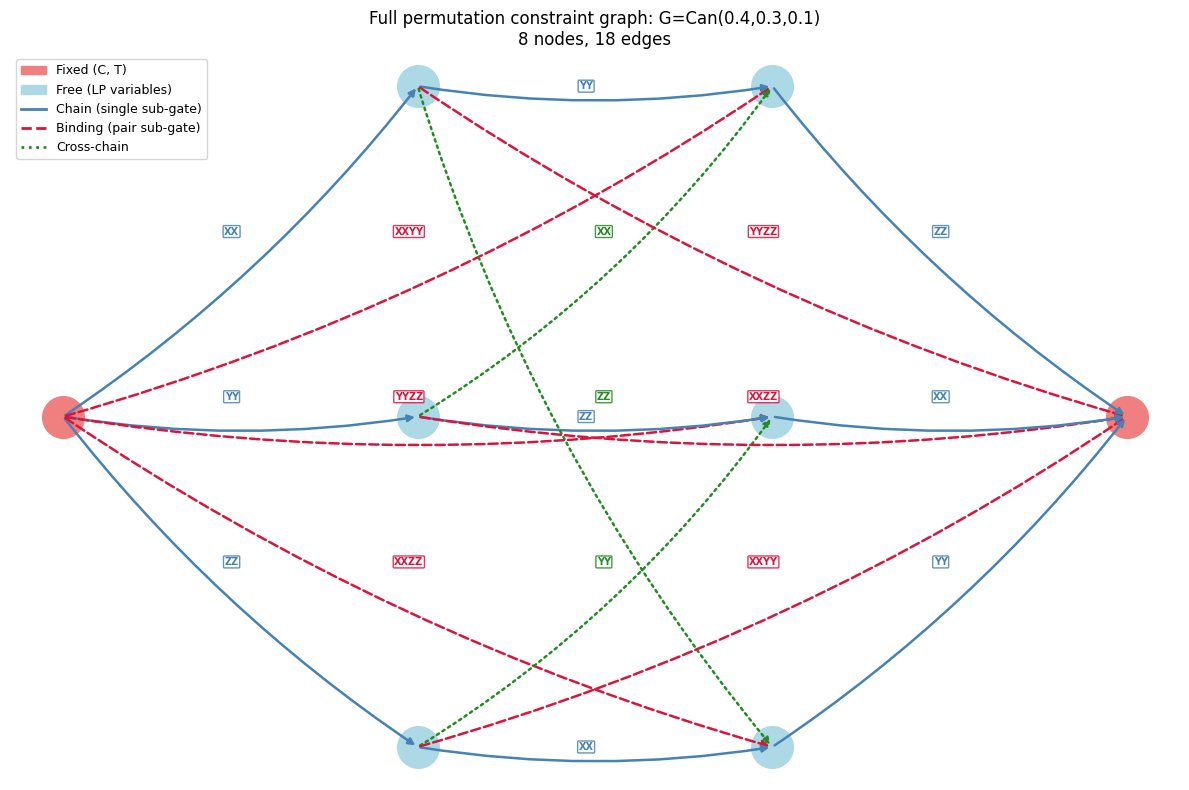

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

pos = {
    "C": (-3, 0),
    "Q1": (-1, 2.5),
    "Q2": (1, 2.5),
    "R1": (-1, 0),
    "R2": (1, 0),
    "S1": (-1, -2.5),
    "S2": (1, -2.5),
    "T": (3, 0),
}

# All 18 edges grouped by type
edge_groups = {
    "C→1": [("C", "Q1", "XX"), ("C", "R1", "YY"), ("C", "S1", "ZZ")],
    "C→2": [("C", "Q2", "XXYY"), ("C", "R2", "YYZZ"), ("C", "S2", "XXZZ")],
    "1→2 chain": [("Q1", "Q2", "YY"), ("R1", "R2", "ZZ"), ("S1", "S2", "XX")],
    "1→2 cross": [("Q1", "S2", "ZZ"), ("R1", "Q2", "XX"), ("S1", "R2", "YY")],
    "1→T": [("Q1", "T", "YYZZ"), ("R1", "T", "XXZZ"), ("S1", "T", "XXYY")],
    "2→T": [("Q2", "T", "ZZ"), ("R2", "T", "XX"), ("S2", "T", "YY")],
}

colors = {
    "C→1": "steelblue",
    "C→2": "crimson",
    "1→2 chain": "steelblue",
    "1→2 cross": "forestgreen",
    "1→T": "crimson",
    "2→T": "steelblue",
}
styles = {
    "C→1": "-",
    "C→2": "--",
    "1→2 chain": "-",
    "1→2 cross": ":",
    "1→T": "--",
    "2→T": "-",
}

# Draw nodes
nx.draw_networkx_nodes(
    nx.Graph(), pos, nodelist=["C", "T"], node_color="lightcoral", node_size=900, ax=ax
)
nx.draw_networkx_nodes(
    nx.Graph(),
    pos,
    nodelist=["Q1", "Q2", "R1", "R2", "S1", "S2"],
    node_color="lightblue",
    node_size=900,
    ax=ax,
)
nx.draw_networkx_labels(nx.Graph(), pos, font_size=11, font_weight="bold", ax=ax)

for group, edges in edge_groups.items():
    col = colors[group]
    rad = 0.1 if "cross" in group else 0.08
    for s, d, l in edges:
        ax.annotate(
            "",
            xy=pos[d],
            xytext=pos[s],
            arrowprops=dict(
                arrowstyle="-|>",
                color=col,
                lw=1.8,
                linestyle=styles[group],
                connectionstyle=f"arc3,rad={rad}",
            ),
        )
        mx = (pos[s][0] + pos[d][0]) / 2
        my = (pos[s][1] + pos[d][1]) / 2
        # Offset labels slightly
        ox = 0.05 if "cross" in group else -0.05
        oy = 0.15 if s[0] != d[0] else 0
        ax.text(
            mx + ox,
            my + oy,
            l,
            fontsize=7,
            ha="center",
            va="center",
            color=col,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.1", fc="white", ec=col, alpha=0.85),
        )

legend = [
    mpatches.Patch(color="lightcoral", label="Fixed (C, T)"),
    mpatches.Patch(color="lightblue", label="Free (LP variables)"),
    plt.Line2D([], [], color="steelblue", lw=2, label="Chain (single sub-gate)"),
    plt.Line2D([], [], color="crimson", lw=2, ls="--", label="Binding (pair sub-gate)"),
    plt.Line2D([], [], color="forestgreen", lw=2, ls=":", label="Cross-chain"),
]
ax.legend(handles=legend, loc="upper left", fontsize=9)
ax.set_title(
    f"Full permutation constraint graph: G=Can({a},{b},{c})\n8 nodes, 18 edges",
    fontsize=12,
)
ax.axis("off")
plt.tight_layout()
plt.show()